In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [10]:
df.shape

(1000, 8)

In [14]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [18]:
df.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [22]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [24]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

## Observation

There are no missing values in the dataset, so no imputation or row removal is necessary.

The dataset contains 1000 observations and 8 variables, which is a reasonable size for building a machine learning model.

In [34]:
df["gender"].value_counts()

gender
female    518
male      482
Name: count, dtype: int64

## Observation

The dataset is fairly balanced with 518 female students and 482 male students, so gender imbalance is unlikely to significantly affect the model.

In [36]:
df["test preparation course"].value_counts()

test preparation course
none         642
completed    358
Name: count, dtype: int64

In [38]:
df["parental level of education"].value_counts()

parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

In [40]:
df['writing score'].min()

10

In [58]:
df["math score"].max()

100

In [42]:
df.groupby('gender')[["math score", "reading score", "writing score"]].mean()

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


## Observation

Female students have higher average reading and writing scores, while male students have a higher average math score in this dataset.

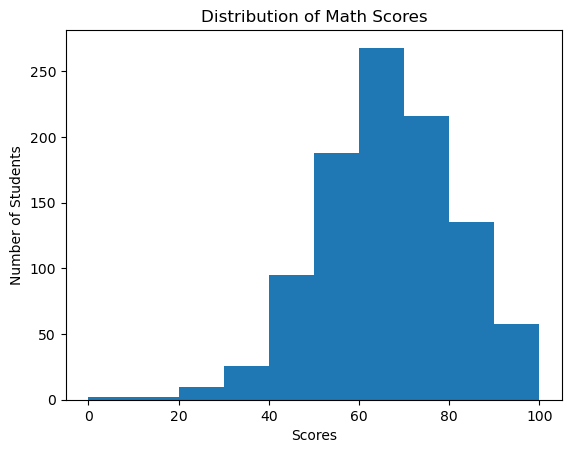

In [48]:
plt.hist(df["math score"])

plt.title("Distribution of Math Scores")
plt.xlabel("Scores")
plt.ylabel("Number of Students")

plt.show()

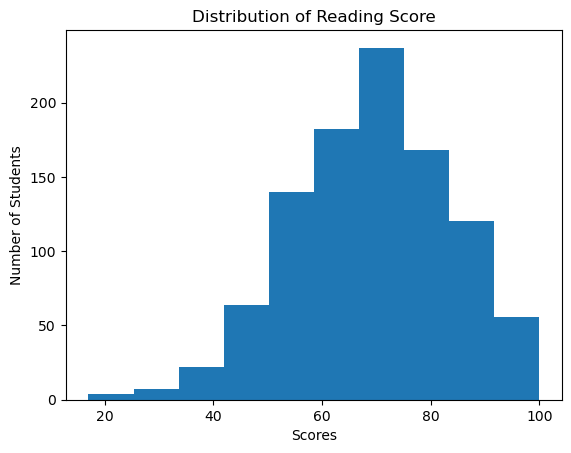

In [54]:
plt.hist(df["reading score"])

plt.title("Distribution of Reading Score")
plt.xlabel("Scores")
plt.ylabel("Number of Students")

plt.show()

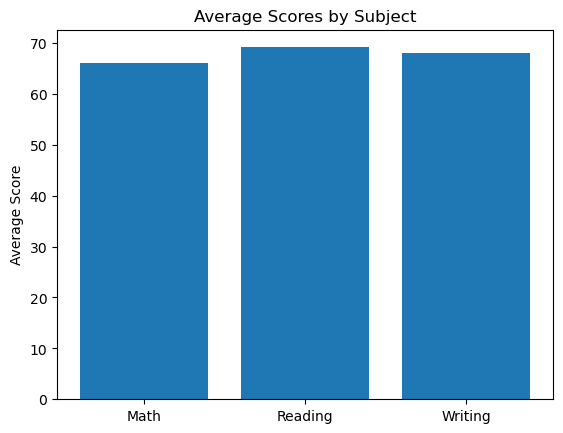

In [56]:
math_avg = df["math score"].mean()
read_avg = df["reading score"].mean()
writing_avg = df["writing score"].mean()

subjects = ["Math", 'Reading', 'Writing']
averages = [math_avg, read_avg, writing_avg]

plt.bar(subjects, averages)

plt.title('Average Scores by Subject')
plt.ylabel('Average Score')

plt.show()

In [63]:
df.groupby("test preparation course")[["math score", "reading score", "writing score"]].mean()

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


In [65]:
df.groupby("parental level of education")[["math score", "reading score", "writing score"]].mean()

,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


In [67]:
df.groupby("lunch")[["math score", "reading score", "writing score"]].mean()

,math score,reading score,writing score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


## Key Findings

1. The dataset contains 1000 students and 8 features.
2. No missing values were found.
3. Math has the lowest average score, suggesting it is the most challenging subject in this dataset.
4. Students who completed the test preparation course achieved higher average scores in all three subjects.
5. Higher parental education levels appear to be associated with better student performance.
6. Students receiving a standard lunch scored substantially higher on average than students receiving free or reduced lunch.
7. Female students achieved higher average reading and writing scores, while male students achieved higher average math scores.
8. The dataset contains both numerical and categorical features, so categorical variables will require encoding before model training.